<a href="https://colab.research.google.com/github/AREVAL0LAUTARO/AREVAL0LAUTARO/blob/main/Practicas_name_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Download the dataset

In [5]:
!gdown 1UOF-7R5MHXTQcCPp7rPMZTFZZSCmKzko

Downloading...
From (original): https://drive.google.com/uc?id=1UOF-7R5MHXTQcCPp7rPMZTFZZSCmKzko
From (redirected): https://drive.google.com/uc?id=1UOF-7R5MHXTQcCPp7rPMZTFZZSCmKzko&confirm=t&uuid=f06d759b-5746-4e18-9463-6634ac9f2120
To: /content/registered-names-1922-2015.csv
100% 221M/221M [00:02<00:00, 104MB/s]


### Load the dataset

In [6]:
import csv

In [7]:
import os
os.getcwd()

'/content'

In [8]:
# simply open it
with open("/content/registered-names-1922-2015.csv") as csvfile:
    reader = csv.DictReader(csvfile)

    count = 10
    for idx, row in enumerate(reader):
        print(row)
        if idx == count:
            break


{'name': 'Maria', 'count': '314', 'year': '1922'}
{'name': 'Rosa', 'count': '203', 'year': '1922'}
{'name': 'Jose', 'count': '163', 'year': '1922'}
{'name': 'Maria Luisa', 'count': '127', 'year': '1922'}
{'name': 'Carmen', 'count': '117', 'year': '1922'}
{'name': 'Ana', 'count': '113', 'year': '1922'}
{'name': 'Maria Elena', 'count': '112', 'year': '1922'}
{'name': 'Juana', 'count': '111', 'year': '1922'}
{'name': 'Maria Esther', 'count': '109', 'year': '1922'}
{'name': 'Antonio', 'count': '103', 'year': '1922'}
{'name': 'Elena', 'count': '102', 'year': '1922'}


In [9]:
# See the number of rows
with open("/content/registered-names-1922-2015.csv") as csvfile:
    reader = csv.DictReader(csvfile)

    count = 0
    for row in reader:
        count =+ 1
    print(count)

1


***How many people were registered each year?***

In [28]:
import pandas as pd
df = pd.read_csv('/content/registered-names-1922-2015.csv')
df.head()

df.columns
people_per_year = df.groupby('year')['count'].sum().reset_index()
people_per_year.head()


,year,count
0,1922,23667
1,1923,30289
2,1924,39075
3,1925,48328
4,1926,58350


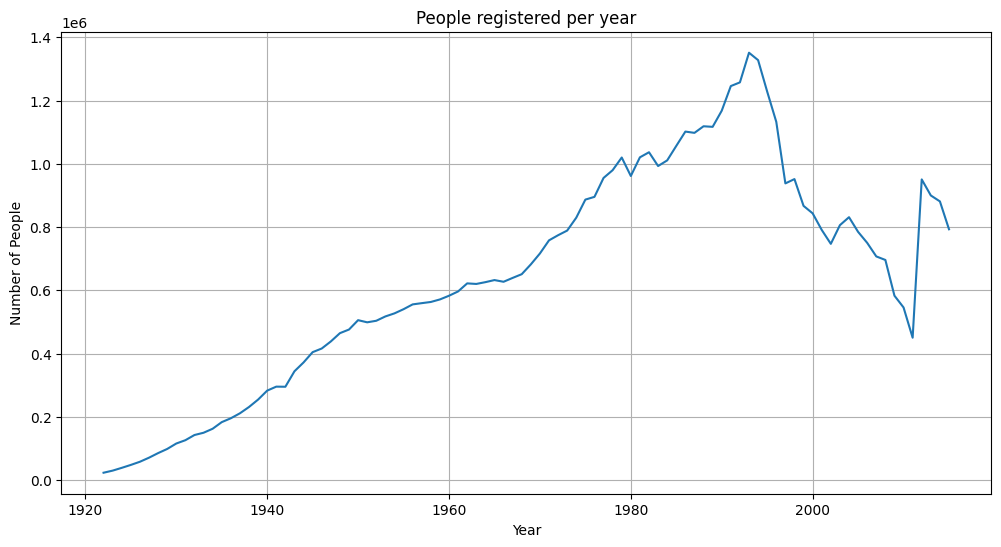

In [30]:
#con la opcion de graficar:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(people_per_year['year'], people_per_year['count'])
plt.title('People registered per year')
plt.xlabel('Year')
plt.ylabel('Number of People')
plt.grid(True)
plt.show()

#2 What is the shorter name in the dataset?
#3 What is the largest name in the dataset?

In [34]:
df['name_length'] = df['name'].str.len()
shortest_name = df.loc[df['name_length'].idxmin(), 'name']
longest_name = df.loc[df['name_length'].idxmax(), 'name']

print("The shortest name is:", shortest_name)
print("The longest name is :", longest_name)

The shortest name is: E
The longest name is : Juan Atanacio                                                                                       


# Is there a name in the dataset that is a Palindrome?

In [36]:
def es_palindromo(s):
    if not isinstance(s, str):
        return False
    s = s.lower()
    return s == s[::-1]

palindromos = df['name'].drop_duplicates().apply(es_palindromo)
nombres_palindromos = df.loc[df['name'].isin(df['name'].drop_duplicates()[palindromos]), 'name'].unique()

print("Palindromic names in the dataset:", nombres_palindromos)



Palindromic names in the dataset: ['Ana' 'Ada' 'Anna' 'Ede' 'Ebe' 'Otto' 'Eve' 'Natan' 'Daad' 'Ene' 'Alila'
 'Edde' 'Oto' 'Alla' 'Samas' 'Odo' 'Sabas' 'Lil' 'Najan' 'Anina' 'Ara'
 'Ivi' 'Oro' 'Itati' 'Nizin' 'Aidia' 'Ili' 'Nissin' 'Enne' 'Emme' 'Savas'
 'Ala' 'Aviva' 'Awiwa' 'Adda' 'ANINA' 'Aziza' 'HANNAH' 'Isasi' 'Asa'
 'Neven' 'Xxx' 'Idi' 'Afa' 'Anuna' 'Ama' 'ILI' 'Rever' 'OPO' 'Oddo'
 'MABAM' 'XXXX' 'XX' '----' 'Ailed Delia' 'Silis' 'Ianai' 'Afifa' 'Kok'
 'ALLA' 'Zulema Ameluz' 'NATAN' 'ARA' 'Non' 'Nan' 'Nail Lian' 'Naian'
 'Tafat' 'Aijia' 'Hannah' 'Abba' 'I I' 'Xxxx' 'Nimin' 'Aletse Estela'
 'Naijian' 'Noel Leon' 'Yanay' 'Maram' 'Nurun' '       ' 'XXX' 'MILIM'
 'Tebet' 'An Na' 'Savvas' 'E' 'Nennen' ' ' 'NENNEN' 'Nannan' 'NIVIN'
 'Onno' 'Nitin' 'NANNAN' 'IVI' 'REINIER' 'YENNEY' 'Yeney' 'ITATI' 'Madam'
 'Han Nah' '11111111111' 'Neuen' 'ECE' 'ADA' 'Reinier' 'Aixia' 'Lian Nail'
 'Aia' 'Neyen' 'Iafai' 'YANAY' ',' 'Nayan' 'NAUAN' 'Pylyp' 'Lewel' 'ABBA'
 'Newen' 'Laial' 'OTTO' 'AVIVA' 'Na

# ***What is the name with the largest number of people registered?***

In [37]:
total_por_nombre = df.groupby('name')['count'].sum()

nombre_mas_registrado = total_por_nombre.idxmax()
cantidad_maxima = total_por_nombre.max()

print(f"The name with the largest number of people registered is '{nombre_mas_registrado}' with {cantidad_maxima} registrations")

The name with the largest number of people registered is 'Juan Carlos' with 288532 registrations
